In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm, t
from statsmodels.tsa.stattools import adfuller
plt.style.use('bmh')

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the datasets
bar_bnc = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crypto_com/bar_bnc.csv')
bar_hb = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crypto_com/bar_hb.csv')

orderbook_bnc = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crypto_com/orderbook_bnc.csv')
orderbook_hb = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crypto_com/orderbook_hb.csv')

# Convert the timestamp datatypes
bar_bnc['timestamp'] = pd.to_datetime(bar_bnc['timestamp'])
bar_hb['timestamp'] = pd.to_datetime(bar_hb['timestamp'])
orderbook_bnc['timestamp'] = pd.to_datetime(orderbook_bnc['timestamp'])
orderbook_hb['timestamp'] = pd.to_datetime(orderbook_hb['timestamp'])

First of all, let's take a look at the data we have here. It looks good overall from the describe() table, no outlier is detected.

In [ ]:
display(bar_bnc)
display(bar_bnc.describe())

,timestamp,symbol,open,high,low,close,volume
0,2021-08-20 00:00:00,LINKUSDT.BNC,27.101,27.101,27.101,27.101,0.74
1,2021-08-20 00:00:01,LINKUSDT.BNC,27.100,27.100,27.095,27.095,509.39
2,2021-08-20 00:00:02,LINKUSDT.BNC,27.095,27.100,27.090,27.090,483.85
3,2021-08-20 00:00:03,LINKUSDT.BNC,27.100,27.101,27.100,27.101,19.82
4,2021-08-20 00:00:04,LINKUSDT.BNC,27.092,27.092,27.091,27.091,2.82
...,...,...,...,...,...,...,...
5095,2021-08-20 01:59:53,LINKUSDT.BNC,27.259,27.260,27.259,27.260,2.92
5096,2021-08-20 01:59:55,LINKUSDT.BNC,27.260,27.260,27.260,27.260,14.95
5097,2021-08-20 01:59:56,LINKUSDT.BNC,27.261,27.261,27.257,27.257,280.49
5098,2021-08-20 01:59:57,LINKUSDT.BNC,27.253,27.253,27.253,27.253,0.68


,open,high,low,close,volume
count,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000
mean,27.159115,27.161486,27.156594,27.158999,134.489310
std,0.125297,0.125535,0.125214,0.125367,412.667296
min,26.781000,26.781000,26.781000,26.781000,0.010000
25%,27.083000,27.085750,27.081000,27.083000,6.402500
50%,27.159000,27.161000,27.157000,27.159000,36.260000
75%,27.252000,27.255000,27.250000,27.252000,117.830000
max,27.427000,27.430000,27.416000,27.427000,9206.250000


In [ ]:
display(bar_hb)
display(bar_hb.describe())

,timestamp,symbol,open,high,low,close,volume
0,2021-08-20 00:00:00,LINKUSDT.HB,27.1000,27.1000,27.0999,27.0999,39.54
1,2021-08-20 00:00:01,LINKUSDT.HB,27.0923,27.0923,27.0923,27.0923,0.20
2,2021-08-20 00:00:02,LINKUSDT.HB,27.0923,27.0923,27.0923,27.0923,2.00
3,2021-08-20 00:00:05,LINKUSDT.HB,27.0924,27.0924,27.0924,27.0924,4.00
4,2021-08-20 00:00:06,LINKUSDT.HB,27.0925,27.0925,27.0925,27.0925,0.74
...,...,...,...,...,...,...,...
3816,2021-08-20 01:59:40,LINKUSDT.HB,27.2635,27.2635,27.2635,27.2635,0.37
3817,2021-08-20 01:59:41,LINKUSDT.HB,27.2646,27.2646,27.2645,27.2645,13.28
3818,2021-08-20 01:59:44,LINKUSDT.HB,27.2501,27.2501,27.2501,27.2501,3.72
3819,2021-08-20 01:59:45,LINKUSDT.HB,27.2475,27.2563,27.2475,27.2563,5.38


,open,high,low,close,volume
count,3821.000000,3821.000000,3821.000000,3821.000000,3821.000000
mean,27.160353,27.162268,27.158124,27.160125,95.058775
std,0.132242,0.132469,0.131991,0.132234,334.706227
min,26.784000,26.784000,26.784000,26.784000,0.000000
25%,27.074500,27.076700,27.073500,27.074400,2.730000
50%,27.162600,27.163700,27.160600,27.162400,15.260000
75%,27.262000,27.264600,27.260100,27.261800,64.280000
max,27.400000,27.400000,27.400000,27.400000,7198.110000


In [ ]:
orderbook_bnc.loc[:, ['timestamp', 'symbol', 'b2', 'bv2', 'b1', 'bv1', 'a1', 'av1', 'a2', 'av2']].head(5)

,timestamp,symbol,b2,bv2,b1,bv1,a1,av1,a2,av2
0,2021-08-20 00:00:00,LINKUSDT.BNC,27.088,215.284,27.095,988.450,27.101,21.079,27.105,163.422
1,2021-08-20 00:00:01,LINKUSDT.BNC,27.089,13.122,27.095,964.450,27.100,21.079,27.104,25.909
2,2021-08-20 00:00:02,LINKUSDT.BNC,27.090,15.574,27.095,462.036,27.096,20.000,27.100,14.871
3,2021-08-20 00:00:03,LINKUSDT.BNC,27.089,41.693,27.090,23.642,27.100,1.079,27.101,24.000
4,2021-08-20 00:00:04,LINKUSDT.BNC,27.091,24.314,27.093,1.079,27.101,5.265,27.103,18.455


In [ ]:
orderbook_hb.loc[:, ['timestamp', 'symbol', 'b2', 'bv2', 'b1', 'bv1', 'a1', 'av1', 'a2', 'av2']].head(5)

,timestamp,symbol,b2,bv2,b1,bv1,a1,av1,a2,av2
0,2021-08-20 00:00:00,LINKUSDT.HB,27.0946,22.00,27.0999,10.67,27.1000,83.08,27.1001,32.18
1,2021-08-20 00:00:01,LINKUSDT.HB,27.0913,7.97,27.0920,22.00,27.0947,2.99,27.1000,54.21
2,2021-08-20 00:00:02,LINKUSDT.HB,27.0905,5.48,27.0923,7.97,27.0938,32.18,27.0947,2.99
3,2021-08-20 00:00:03,LINKUSDT.HB,27.0874,1.02,27.0923,6.36,27.0924,33.83,27.0946,30.84
4,2021-08-20 00:00:04,LINKUSDT.HB,27.0884,22.00,27.0923,5.36,27.0924,33.83,27.0925,30.84


<Axes: xlabel='timestamp'>

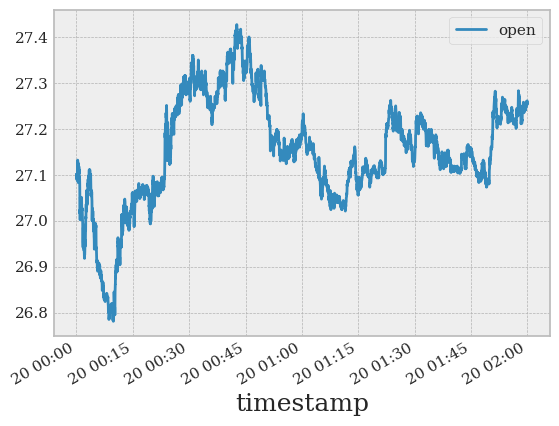

In [ ]:
bar_bnc.plot(x='timestamp', y='open', kind='line')

 # 1. Preparatory Analysis

In [ ]:
# Use the weighted mid price as fair price
wmid_price_bnc = (orderbook_bnc['b1']*orderbook_bnc['av1'] + orderbook_bnc['a1']*orderbook_bnc['bv1'])/(orderbook_bnc['av1'] + orderbook_bnc['bv1'])
wmid_price_hb = (orderbook_hb['b1']*orderbook_hb['av1'] + orderbook_hb['a1']*orderbook_hb['bv1'])/(orderbook_hb['av1'] + orderbook_hb['bv1'])
spread = wmid_price_bnc - wmid_price_hb

df = pd.concat([orderbook_bnc['timestamp'], wmid_price_bnc, wmid_price_hb, spread], axis=1)
df.columns = ['timestamp', 'wmid_bnc', 'wmid_hb', 'spread']
df.head(5)

,timestamp,wmid_bnc,wmid_hb,spread
0,2021-08-20 00:00:00,27.100875,27.099911,0.000963
1,2021-08-20 00:00:01,27.099893,27.094377,0.005516
2,2021-08-20 00:00:02,27.095959,27.092598,0.003361
3,2021-08-20 00:00:03,27.099564,27.092316,0.007248
4,2021-08-20 00:00:04,27.094361,27.092314,0.002047


Also we may plot the histogram of the spread. Here we plot it against the fitted normal distribution, we may notice that the spread is well centered around zero, which reassures us that we can assume symmetrical thresholds for trading.

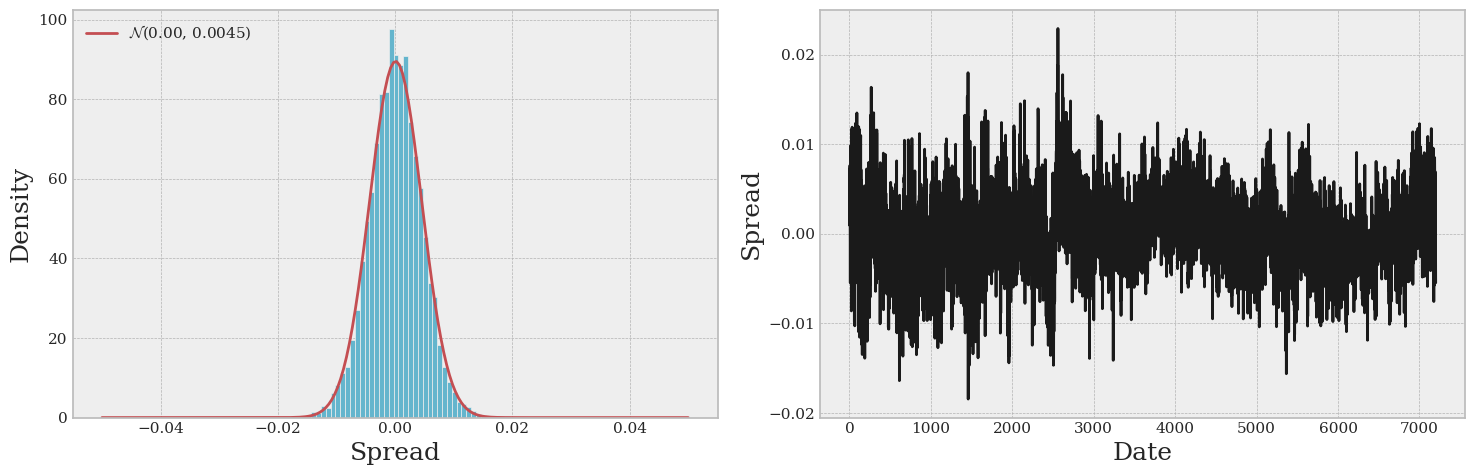

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].hist(df.spread, bins=50, facecolor='c', density=True)
x_grid = np.linspace(-.05, .05, 200)

# fit to normal
params = norm.fit(df.spread)
pdf_fitted = norm.pdf(x_grid, *params)
axs[0].plot(x_grid, pdf_fitted, color='r',
         label='$\mathcal{N}$' + f'({params[0]:.2f}, {params[1]:.4f})')

axs[0].set_xlabel('Spread')
axs[0].set_ylabel('Density')
axs[0].legend(frameon=False, loc='upper left')

axs[1].plot(df.spread, color='k')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Spread')

plt.xticks(rotation=0, ha='center')
plt.tight_layout()

In the second subplot, we can see that the spread series is quite “stationary” over time, but we’d better not stop just observing by eye. (Also it’s a bit heteroskedastic, but we’re not focusing on that in this research.)

**Statistical Tests**

Below are some statistical tests we need to run through before actual pair traing. For detailed reasoning please refer to this [post](https://www.quantstart.com/articles/Basics-of-Statistical-Mean-Reversion-Testing/).

- Test for Unit Root: Here we use the Augmented Dickey-Fuller test. The p-value is 1.07e-13 $\ll$ 0.05, so we may safely reject the null.

In [ ]:
# Statistical Tests
result = adfuller(df.spread)
print(f'ADF Statistic: {result[0]}\np-value: {result[1]}\nCritical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.3f}')

ADF Statistic: -8.525761705432243
p-value: 1.0703077473443047e-13
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


- Test for Strong Stationarity: Here we opt for the Hurst Exponent. By definition, Hurst value H < 0.5 indicates the time series is mean-reverting, and our H value for the spread is 0.0476, so assumption is confirmed.

In [ ]:
def hurst_exponent(ts, max_lag=100):
  """
  Returns the Hurst Exponent of the time series.
  Depending on the choice of the maximum lag parameter (i.e., whether we are looking for short or long term), the results can differ significantly.
  """
  if isinstance(ts, pd.Series):
      ts = ts.to_numpy()

  lags = range(2, max_lag)
  tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
  hurst = np.polyfit(np.log(lags), np.log(tau), 1)[0]

  return hurst

print(f'H: {hurst_exponent(df.spread):.4f}')

H: 0.0476


# 2. Backtest

In this strategy we try to do spread trading based on the mid-price between Binance and Huobi. The intuition is to hedge the one-sided risks of buy-and-holding LINK on one exchange by holding an opposite position of LINK on another exchange. Once we have that the same asset on two different exchanges are highly correlated, we can trade and make profit by this sort of pair trading.

We define trading thresholds $g$ and $j$, together with stop-loss threshold $s$.

For simplicity, our position of LINK will only be $-1$, $0$ or $1$ for both exchanges at any time $t$.

Specifically, for each trading day, we have workflow as below:

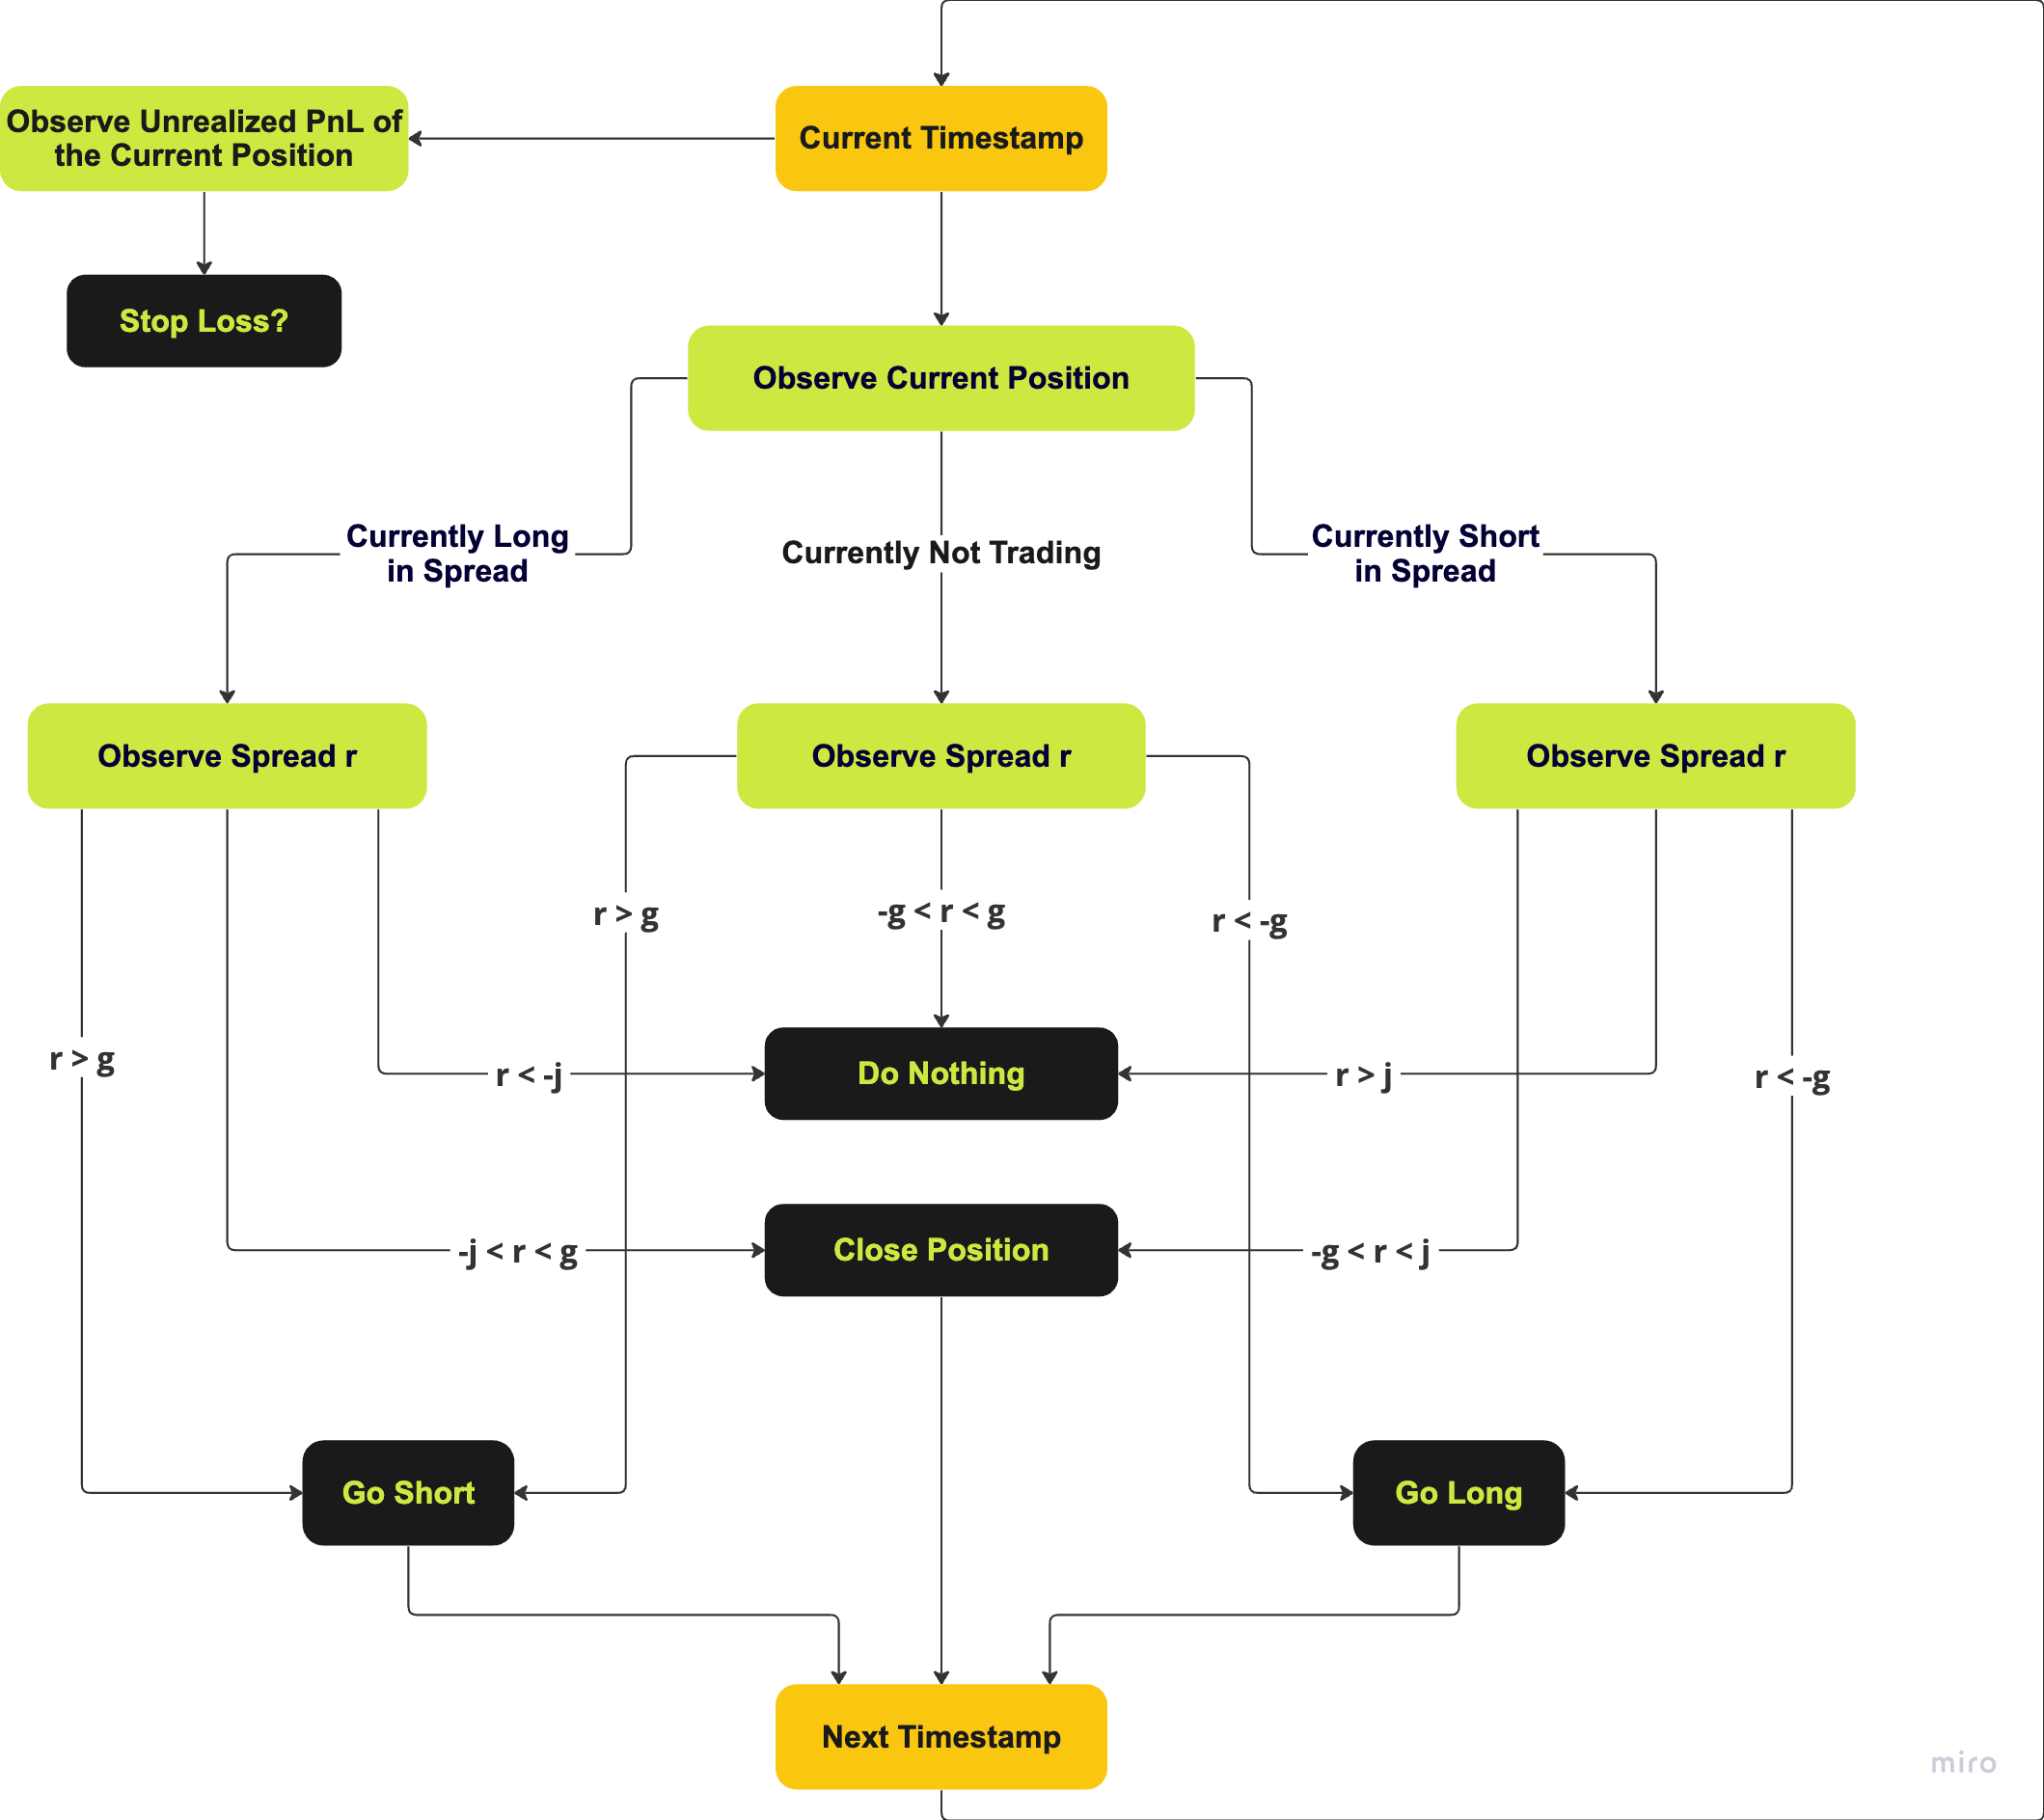

In [ ]:
from IPython.display import Image

image_path = '/content/drive/MyDrive/Colab Notebooks/Crypto_com/StatArb_Workflow.png'

# Display the image
Image(filename=image_path, width=800, height=800)

In [ ]:
class BacktestEngine:
    def __init__(self):
        self.__data = None
        self.__capital = 60 # capital needed to long and short 1 LINK on two exchanges

    def load_data(self, filename_A, filename_B, root_dir='../'): # prepare data to feed model
        '''
        PARAMS:
            filename_A: string
            filename_B: string
            root_dir: string (end with '/', default: '../')
        RETURN: None
        '''
        orderbook_A = pd.read_csv(root_dir + filename_A)
        orderbook_B = pd.read_csv(root_dir + filename_B)

        # Convert the timestamp datatypes
        orderbook_A['timestamp'] = pd.to_datetime(orderbook_A['timestamp'])
        orderbook_B['timestamp'] = pd.to_datetime(orderbook_B['timestamp'])

        # Concat variables
        wmid_price_A = (orderbook_A['b1']*orderbook_A['av1'] + orderbook_A['a1']*orderbook_A['bv1'])/(orderbook_A['av1'] + orderbook_A['bv1'])
        wmid_price_B = (orderbook_B['b1']*orderbook_B['av1'] + orderbook_B['a1']*orderbook_B['bv1'])/(orderbook_B['av1'] + orderbook_B['bv1'])
        spread = wmid_price_A - wmid_price_B

        df = pd.concat([orderbook_A['timestamp'], wmid_price_A, wmid_price_B, spread], axis=1)
        df.columns = ['timestamp', 'wmid_A', 'wmid_B', 'spread']

        self.__data = df

    def __update_params(self, g, j, s):  # update parameters of the model
        '''
        PARAMETER:
            g: float
            j: float
            s: float

        RETURN: None
        '''
        assert -g < j < g, 'parameter j and g should follow -g < j < g'
        assert 0 < s, 'parameter s should be positive'

        self.__g = g
        self.__j = j
        self.__s = s

        self.tradelogs = []
        self.__orderID = 0
        self.__stop_loss_time = []


    @staticmethod
    def __posval(position, price1, price2, gross=False):  # calculate position value
        '''
        PARAMETER:
            position: float
            price1: float
            price2: float
            gross: boolean (default: False)

        RETURN: float
        '''

        if gross:
            return abs(position[0]) * price1 + abs(position[1]) * price2
        else:
            return position[0] * price1 + position[1] * price2

    def __sendorder(self, time, current_position, orderType, price1, price2, vol1, vol2):
        '''
        PARAMETER:
            time: datetime
            orderType: string
            price1: float
            price2: float
            vol1: int
            vol2: int

        RETURN: None
        '''
        self.__orderID += 1
        order_info = {
          'Timestamp': time,
          'order_ID': self.__orderID,
          'order_Type': orderType,
          'curr_pos_A': current_position[0],
          'curr_pos_B': current_position[1],
          'order_send_price_A': price1,
          'order_volume_A': vol1,
          'order_send_price_B': price2,
          'order_volume_B': vol2
          }
        self.tradelogs.append(order_info)

    @staticmethod
    def __sharpe_ratio(seconds_rtn):  # calculate sharpe ratio
        '''
        PARAMETER:
            seconds_rtn: pd.Series of float

        RETURN: float
        '''

        return seconds_rtn.mean() / seconds_rtn.std()

    @staticmethod
    def __sortino_ratio(seconds_rtn):  # calculate sortino ratio
        '''
        PARAMETER:
            seconds_rtn: pd.Series of float

        RETURN: float
        '''
        seconds_rtn = seconds_rtn.copy()
        mean_rtn = seconds_rtn.mean()
        seconds_rtn.loc[seconds_rtn > 0] = 0
        downside_risk = seconds_rtn.std()
        return mean_rtn / downside_risk

    @staticmethod
    def __maximum_drawdown(value):  # maximum drawdown
        '''
        PARAMETER:
            value: pd.Series of float

        RETURN: (float, datetime, datetime)
        '''

        end = (value.cummax() / value).idxmax()
        start = (value.loc[:end]).idxmax()
        mdd = 1 - value[end] / value[start]
        return mdd, start, end

    def __plot(self):  # plot backtest results
        '''
        PARAMETER: None

        RETURN: None
        '''

        fig, axs = plt.subplots(1, 2, figsize=(15, 5))

        axs[0].plot(self.__data['timestamp'], self.__data.spread, label='spread', color='k')
        axs[0].plot((min(self.__data.timestamp), max(self.__data.timestamp)),
                 (self.__g, self.__g), 'c--', label='$\pm$g')
        axs[0].plot((min(self.__data.timestamp), max(self.__data.timestamp)),
                 (self.__j, self.__j), 'r--', label='$\pm$j')
        axs[0].plot((min(self.__data.timestamp), max(self.__data.timestamp)),
                 (-self.__g, -self.__g), 'c--')
        axs[0].plot((min(self.__data.timestamp), max(self.__data.timestamp)),
                 (-self.__j, -self.__j), 'r--')
        axs[0].set_ylabel('Spread')
        plt.xticks(rotation=0, ha='center')
        axs[0].legend()

        axs[1].plot(self.__data['timestamp'], self.__data.cum_rtn * 100, label='Cum. Return (%)', color='r')
        axs[1].set_ylabel('Return (%)')
        plt.xticks(rotation=0, ha='center')
        axs[1].legend()

        plt.tight_layout()
        plt.show()

    def run(self, g, j, s, verbose=False):  # run backtest using parameters
        '''
        PARAMETER:
            g: float
            j: float
            s: float
            verbose: boolean (default: True)

        RETURN: None
        '''
        self.__update_params(g, j, s)

        pos_A = [] # positions
        pos_B = []
        rtn = []

        curr_position = (0, 0)
        curr_rtn = 0

        last_price_A = 0
        last_price_B = 0

        initial_val = 0
        initial_gross_val = 0

        # Iterate every seconds
        for index, row in self.__data.iterrows():
            timestamp = row['timestamp']
            price_A = row['wmid_A']
            price_B = row['wmid_B']
            spread = row['spread']

            prev_val = self.__posval(curr_position, last_price_A, last_price_B)
            curr_val = self.__posval(curr_position, price_A, price_B)
            curr_rtn = curr_val - prev_val

            pos_A.append(curr_position[0])
            pos_B.append(curr_position[1])
            rtn.append(curr_rtn)

          if curr_val-initial_val < -self.__s * initial_gross_val:  # stop loss
              self.__sendorder(timestamp, curr_position,
                               'Stop Loss', price_A, price_B,
                               -curr_position[0], -curr_position[1])
              self.__stop_loss_time.append(timestamp)
              curr_position = (0, 0)

          else:
             if curr_position[0] > 0:  # currently long spread (p_Binance - p_Huobi)
                if spread > self.__g:  # direactly from long to short
                    self.__sendorder(timestamp, curr_position,
                                     'Long to Short', price_A, price_B,
                                     -1-curr_position[0], 1-curr_position[0])
                    curr_position = (-1, 1)
                    initial_val = self.__posval(curr_position, price_A, price_B)
                    initial_gross_val = self.__posval(curr_position, price_A, price_B, True)
                elif spread > -self.__j:  # close position
                    self.__sendorder(timestamp, curr_position,
                                     'Close Position', price_A, price_B,
                                     -curr_position[0], -curr_position[0])
                    curr_position = (0, 0)
                    initial_val = self.__posval(curr_position, price_A, price_B)
                    initial_gross_val = self.__posval(curr_position, price_A, price_B, True)
             elif curr_position[0] < 0:  # currently short spread
                seconds_return = curr_rtn
                if spread < -self.__g:  # directly from short to long
                    self.__sendorder(timestamp, curr_position,
                                     'Short to Long', price_A, price_B,
                                     1-curr_position[0], -1-curr_position[0])
                    curr_position = (1, -1)
                    initial_val = self.__posval(curr_position, price_A, price_B)
                    initial_gross_val = self.__posval(curr_position, price_A, price_B, True)
                elif spread < self.__j:  # close position
                    self.__sendorder(timestamp, curr_position,
                                     'Close Position', price_A, price_B,
                                     -curr_position[0], -curr_position[0])
                    curr_position = (0, 0)
                    initial_val = self.__posval(curr_position, price_A, price_B)
                    initial_gross_val = self.__posval(curr_position, price_A, price_B, True)
             else:  # currently having no position
                seconds_return = 0
                if spread > self.__g:  # open short position
                    self.__sendorder(timestamp, curr_position,
                                     'Open Short', price_A, price_B,
                                     -1-curr_position[0], 1-curr_position[0])
                    curr_position = (-1, 1)
                    initial_val = self.__posval(curr_position, price_A, price_B)
                    initial_gross_val = self.__posval(curr_position, price_A, price_B, True)
                elif spread < -self.__g:  # open long position
                    self.__sendorder(timestamp, curr_position,
                                     'Open Long', price_A, price_B,
                                     1-curr_position[0], -1-curr_position[0])
                    curr_position = (1, -1)
                    initial_val = self.__posval(curr_position, price_A, price_B)
                    initial_gross_val = self.__posval(curr_position, price_A, price_B, True)

          last_price_A = price_A
          last_price_B = price_B

        self.__data['pos_A'] = pos_A
        self.__data['pos_B'] = pos_B
        self.__data['seconds_rtn'] = rtn
        self.__data.seconds_rtn /= self.__capital  # rtn is stored in %
        self.__data['cum_rtn'] = self.__data.seconds_rtn.cumsum()

        PnL = sum(rtn) / self.__capital
        sortino = self.__sortino_ratio(self.__data.seconds_rtn)
        sharpe = self.__sharpe_ratio(self.__data.seconds_rtn)
        mdd = self.__maximum_drawdown(self.__data.cum_rtn + self.__capital)[0]
        trade_logs = pd.DataFrame.from_dict(self.tradelogs)
        trade_logs['notional_A'] = trade_logs['order_volume_A'].abs() * trade_logs['order_send_price_A']
        trade_logs['notional_B'] = trade_logs['order_volume_B'].abs() * trade_logs['order_send_price_B']
        moons = sum(rtn)/(trade_logs.notional_A.sum() + trade_logs.notional_B.sum()) * 10000 # Money over our notionals

        if verbose: self.__plot()
        return PnL, sortino, sharpe, mdd, moons, trade_logs

In [ ]:
# Load the backtest engine
be = BacktestEngine()
be.load_data(filename_A='orderbook_bnc.csv', filename_B='orderbook_hb.csv', root_dir='/content/drive/MyDrive/Colab Notebooks/Crypto_com/')

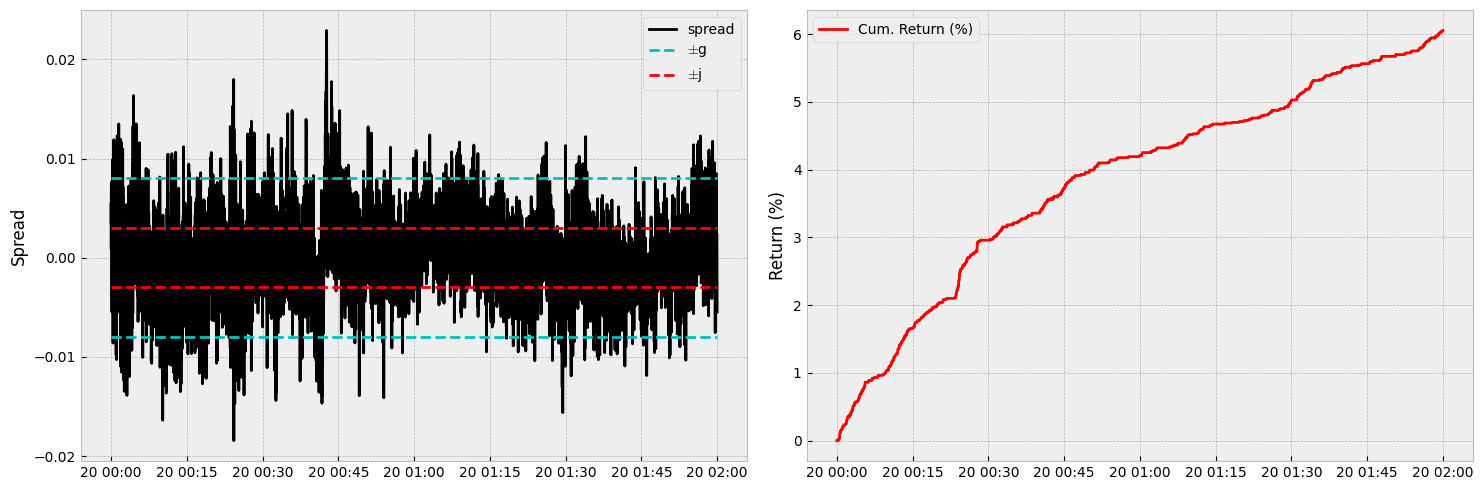

,Timestamp,order_ID,order_Type,curr_pos_A,curr_pos_B,order_send_price_A,order_volume_A,order_send_price_B,order_volume_B,notional_A,notional_B
0,2021-08-20 00:00:17,1,Open Short,0,0,27.122055,-1,27.112178,1,27.122055,27.112178
1,2021-08-20 00:00:21,2,Close Position,-1,1,27.118323,1,27.117280,1,27.118323,27.117280
2,2021-08-20 00:00:23,3,Open Long,0,0,27.121046,1,27.129650,-1,27.121046,27.129650
3,2021-08-20 00:00:24,4,Close Position,1,-1,27.123510,-1,27.122615,-1,27.123510,27.122615
4,2021-08-20 00:00:31,5,Open Short,0,0,27.106829,-1,27.095114,1,27.106829,27.095114
...,...,...,...,...,...,...,...,...,...,...,...
665,2021-08-20 01:59:11,666,Close Position,-1,1,27.233846,1,27.235399,1,27.233846,27.235399
666,2021-08-20 01:59:28,667,Open Short,0,0,27.252792,-1,27.243225,1,27.252792,27.243225
667,2021-08-20 01:59:30,668,Close Position,-1,1,27.252695,1,27.255468,1,27.252695,27.255468
668,2021-08-20 01:59:46,669,Open Short,0,0,27.256000,-1,27.247495,1,27.256000,27.247495


PnL=6.05%, 
Sortino Ratio=0.9600, 
Sharpe Ratio=0.2173, 
Maximum Drawdown=4.367e-06, 
Moons=0.9986bps


In [ ]:
# Try different meta parameters
pnl, st, sr, md, mon, trade_logs = be.run(g=0.008, j=0.003, s=0.01, verbose=True)
display(trade_logs)
print(f'PnL={pnl:.2%}, \nSortino Ratio={st:.4f}, \nSharpe Ratio={sr:.4f}, \nMaximum Drawdown={md:.4g}, \nMoons={mon:.4}bps')

# 3. Parameter Tuning

In this section we try to fit the best set of parameters. As the focus of this report is not about efficient optimization, we opt for a simple grid search here. The parameter grids are defined as:
- g_grid: 0.001, 0.003, …, 0.011 (6 in total)
- j_grid: -0.010, -0.008, …, 0.010 (11 in total)
- s_grid: 1e-4, 5e-4, 1e-3, 5e-3, 1e-2 (5 in total)

In [ ]:
from time import time
from itertools import product

def record():
    # record function with closure designed
    # to keep track of the best parameters
    record.best = []
    def f(*args):
        record.best.append((*args,))
    return f

mpnl, mst, msr, mmd, mmon =0, 0, 0, 1, 0
g_grid = np.arange(0.001, 0.012, 0.002)
j_grid = np.arange(-0.010, 0.011, 0.002)
s_grid = [1e-3, 5e-3, 0.01, 0.05, 0.10]
nsim = len(g_grid) * len(j_grid) * len(s_grid)
report_params = record()

be = BacktestEngine()
be.load_data(filename_A='orderbook_bnc.csv', filename_B='orderbook_hb.csv', root_dir='/content/drive/MyDrive/Colab Notebooks/Crypto_com/')

start_time = time()
for i, params in enumerate(product(g_grid, j_grid, s_grid)):
    try:
        pnl, st, sr, md, mon, tradelogs = be.run(*params, verbose=False)
        if np.isnan(sr) or sr < 0 or st < 0: continue
        report = False
        if pnl > mpnl: mpnl, report = pnl, True
        if st > mst: mst, report = st, True
        if sr > msr: msr, report = sr, True
        if md < mmd: mmd, report = md, True
        if mon > mmon: mmon, report = mon, True
        prog = (i + 1) / nsim
        current_time = time()
        elapse = current_time - start_time
        eta = elapse / prog * (1 - prog)
        print('Running {} simulations... {:.2%} finished, ETA={:.0f}s'
              .format(nsim, prog, eta) + ' ' * 10, end='\r')
        if report: report_params(*params, pnl, st, sr, md, mon)
    except AssertionError:  # (-g < j < g) does not hold
        continue

pnl_list, st_list, sr_list, md_list, mon_list = list(zip(*record.best))[-5:]
record.best = [entries for _, entries in sorted(zip(pnl_list, record.best))][-5:]
record.best = [entries for _, entries in sorted(zip(st_list, record.best))][-5:]
record.best = [entries for _, entries in sorted(zip(sr_list, record.best))][-5:]
record.best = [entries for _, entries in sorted(zip(mon_list, record.best))][-5:]
record.best = [entries for _, entries in sorted(zip(md_list, record.best))][:5]

for i, entries in enumerate(record.best):
    print('(Record {:2}) g={:.3f}, j={:6.3f}, s={:.5f},\t'
          'pnl={:.2%}, st={:.4f}, sr={:.4f}, md={:9.4g}, mon={:.4f}bps'
          .format(i, *entries))

(Record  0) g=0.001, j= 0.000, s=0.00100,	pnl=22.61%, st=1.1557, sr=0.4482, md=4.762e-06, mon=0.9530bps
(Record  1) g=0.003, j=-0.002, s=0.00100,	pnl=15.94%, st=0.6918, sr=0.3070, md= 6.57e-06, mon=1.3224bps
(Record  2) g=0.005, j=-0.004, s=0.00100,	pnl=9.06%, st=0.3340, sr=0.1699, md=6.573e-06, mon=1.8073bps
(Record  3) g=0.003, j= 0.002, s=0.00100,	pnl=18.81%, st=1.4543, sr=0.4360, md=4.763e-06, mon=0.6827bps
(Record  4) g=0.005, j= 0.004, s=0.00100,	pnl=13.17%, st=1.6194, sr=0.3572, md=4.765e-06, mon=0.6889bps


From the two plots below, we can tell that Record 1, or the parameter set g=0.003, j=-0.002, s=0.00100, is a good choice as it has both large money over notional/return. Record 3, or g=0.003, j= 0.002, s=0.00100 is also playing well among all outstanding parameter sets, with better return and Sortino Ratio, however its moons is getting worse.

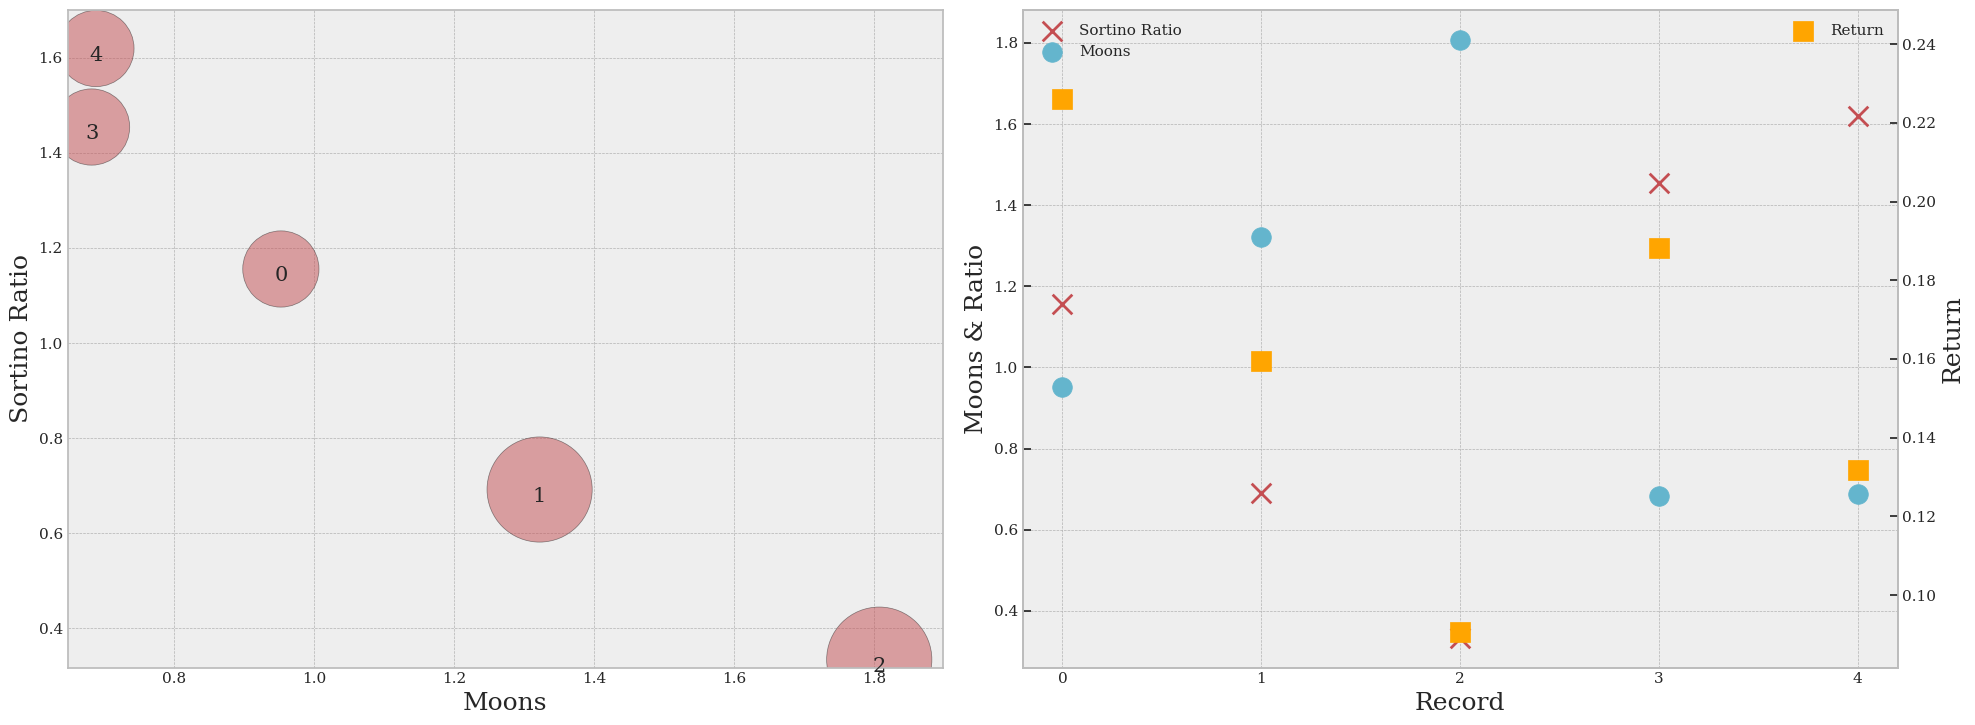

In [ ]:
rec = np.arange(len(record.best))
pnl_list, st_list, sr_list, md_list, mon_list = list(zip(*record.best))[-5:]

fig, axs = plt.subplots(1, 2, figsize = (20,7.5))

axs[0].set_xlim(min(mon_list) * 0.95, max(mon_list) * 1.05)
axs[0].set_ylim(min(st_list) * 0.95, max(st_list) * 1.05)
st_offset = (max(st_list) - min(st_list)) * 0.02
axs[0].scatter(mon_list, st_list, s=[(md / np.mean(md_list))**2 * 4e3 for md in md_list],
           color='r', edgecolor='k', alpha=.5)
for rt, st, i in zip(mon_list, st_list, range(len(record.best))):
    axs[0].text(x=rt, y=st - st_offset, s=str(i), ha='center')
axs[0].set_xlabel('Moons')
axs[0].set_ylabel('Sortino Ratio')

axs[1].scatter(rec, st_list, color='r', marker='x', s=200, label='Sortino Ratio')
axs[1].scatter(rec, mon_list, color='c', marker='o', s=200, label='Moons')
axs[1].set_xlabel('Record')
axs[1].set_ylabel('Moons & Ratio')
axs[1].legend(frameon=False, loc='upper left')

axs[1] = axs[1].twinx()
axs[1].grid(False)
axs[1].scatter(rec, pnl_list, color='orange', marker='s', s=200, label='Return')
axs[1].set_ylim(min(pnl_list) * 0.9, max(pnl_list) * 1.1)
axs[1].xaxis.set_ticks(rec)
axs[1].set_ylabel('Return')
axs[1].legend(frameon=False, loc='upper right')

plt.tight_layout()

# 4. Conclusion

In this report, we implemented a simple arbitrage strategy, which involves profiting from capturing small price differences of the same asset across different exchanges. Furthermore, by adjusting the trading parameters, the strategy demonstrated a noticeable improvement in performance (especially compared with our result using random parameters before any tuning). the performance is satisfactory, despite the fact that we neglected many executional details in our analysis, such as transaction costs and market impacts.

However, it's important to acknowledge that our approach for backtest system and strategy development here has been quite simplistic. For example, one of our assumptions was that backtested orders always execute at the weighted mid-price. This kind of assumption has proven to be unrealistic in practice, but this report still provided valuable insights after detailed analysis.

Given more time, I will try to enhance the practicality of our backtesting enigne as well as strategy from several perspectives:

1. Utilize bar data to assess the transcation event to help determine whether our order will be filled in the short term future.
2. Use the order book data to model the queue of our outstanding orders, thus inferring the probability of our order being filled.
3. Employ dynamic volume instead of fixed numbers in strategy developing.
4. Consider transaction costs and choose between hitting or quoting orders under different scenarios.
5. Consider inventory management in a more detailed way.